# Case Study Assessment — NYC Airbnb Data Preprocessing
### Student Name:ARUNA T G
### Date: 29/09/2026

This notebook is your submission template. Fill in each section — do not delete the headers. Use markdown cells for your written justifications, right next to the code that supports them.

In [1]:
import pandas as pd
url = "https://raw.githubusercontent.com/erkansirin78/datasets/master/AB_NYC_2019.csv"
df = pd.read_csv(url)
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


---
## Part 1 — Data Understanding & Quality Audit

In [2]:
# TODO: shape, dtypes, missing value summary

df.shape

(48895, 16)

In [3]:
df.dtypes

,0
id,int64
name,object
host_id,int64
host_name,object
neighbourhood_group,object
neighbourhood,object
latitude,float64
longitude,float64
room_type,object
price,int64


In [4]:
df.isnull().sum()    # check missing value

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [5]:
# TODO: check for values that are technically present but don't make real-world sense

df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [6]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [7]:
df[df['price']==0]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
23161,18750597,"Huge Brooklyn Brownstone Living, Close to it all.",8993084,Kimberly,Brooklyn,Bedford-Stuyvesant,40.69023,-73.95428,Private room,0,4,1,2018-01-06,0.05,4,28
25433,20333471,★Hostel Style Room | Ideal Traveling Buddies★,131697576,Anisha,Bronx,East Morrisania,40.83296,-73.88668,Private room,0,2,55,2019-06-24,2.56,4,127
25634,20523843,"MARTIAL LOFT 3: REDEMPTION (upstairs, 2nd room)",15787004,Martial Loft,Brooklyn,Bushwick,40.69467,-73.92433,Private room,0,2,16,2019-05-18,0.71,5,0
25753,20608117,"Sunny, Quiet Room in Greenpoint",1641537,Lauren,Brooklyn,Greenpoint,40.72462,-73.94072,Private room,0,2,12,2017-10-27,0.53,2,0
25778,20624541,Modern apartment in the heart of Williamsburg,10132166,Aymeric,Brooklyn,Williamsburg,40.70838,-73.94645,Entire home/apt,0,5,3,2018-01-02,0.15,1,73
25794,20639628,Spacious comfortable master bedroom with nice ...,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68173,-73.91342,Private room,0,1,93,2019-06-15,4.28,6,176
25795,20639792,Contemporary bedroom in brownstone with nice view,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68279,-73.91170,Private room,0,1,95,2019-06-21,4.37,6,232
25796,20639914,Cozy yet spacious private brownstone bedroom,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68258,-73.91284,Private room,0,1,95,2019-06-23,4.35,6,222
26259,20933849,the best you can find,13709292,Qiuchi,Manhattan,Murray Hill,40.75091,-73.97597,Entire home/apt,0,3,0,NaN,NaN,1,0
26841,21291569,Coliving in Brooklyn! Modern design / Shared room,101970559,Sergii,Brooklyn,Bushwick,40.69211,-73.90670,Shared room,0,30,2,2019-06-22,0.11,6,333


In [8]:
# TODO: duplicate check
df.duplicated().sum()

np.int64(0)

**Written notes — what did you find, and what looks suspicious?**

* The data set contains 48895 rows and 16 columns.  
* The dataset contains both numerical and categorical columns.

* Some columns like name, host_name,last_review,
reviews_per_month contain missing values.no duplicate datas.







---
## Part 2 — Missing Value Diagnosis & Treatment

In [9]:
# TODO: investigate missingness pattern(s) across columns
df.isnull().sum()


,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [10]:
(df.isna().sum()/len(df))*100

,0
id,0.000000
name,0.032723
host_id,0.000000
host_name,0.042949
neighbourhood_group,0.000000
neighbourhood,0.000000
latitude,0.000000
longitude,0.000000
room_type,0.000000
price,0.000000


In [11]:
df['last_review'].isna().sum()

np.int64(10052)

In [12]:
df['reviews_per_month'].isna().sum()

np.int64(10052)

**Written justification — MCAR / MAR / MNAR classification per column, and your reasoning:**

Diagnosis: Missing values in last_review and reviews_per_month are identical because those properties received zero reviews.  
Treatment:
last_review: Dropped due to high missing percentage 20%.  
reviews_per_month: Missing values are imputed with 0.



In [13]:
# TODO: apply your chosen treatment(s)

df=df.drop(['last_review','id','name','host_id','host_name'],axis=1)


In [14]:
df['reviews_per_month']=df['reviews_per_month'].fillna(0)

In [15]:
df.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


**Written justification — why this treatment for each column, and what you'd risk with `dropna()` instead:**

 keep the columns and give an imaginary date but that could influence model too much as its over 20% so  rather risk with dropping the column. But this method can cause lose in current popularity and booking recency in the data._

---
## Part 3 — Outlier Detection & Treatment

In [16]:
# TODO: detect outliers in at least two numeric columns

df.columns


Index(['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude',
       'room_type', 'price', 'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

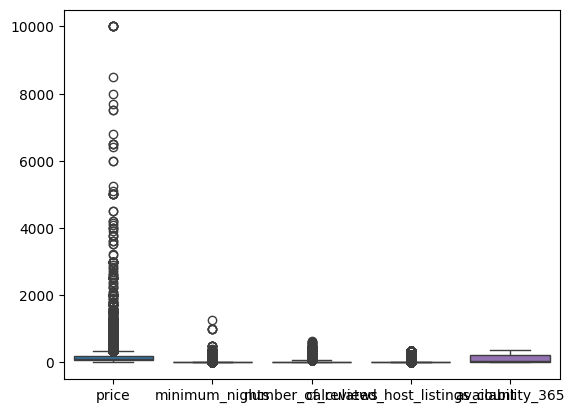

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.boxplot(df[['price', 'minimum_nights', 'number_of_reviews',
       'calculated_host_listings_count', 'availability_365']])
plt.show()

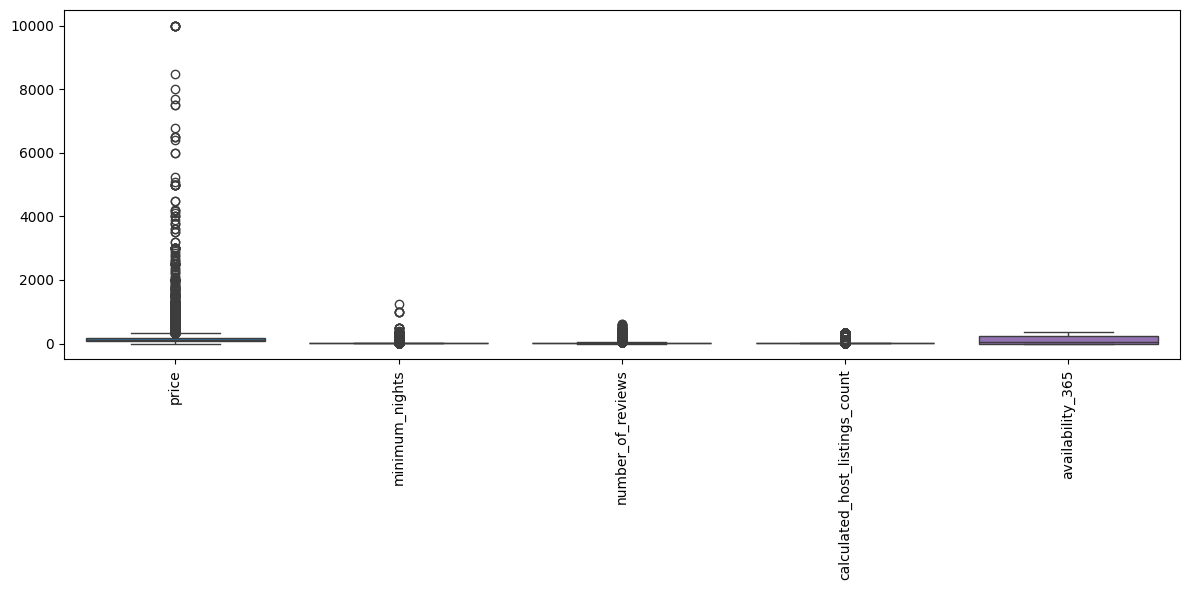

In [18]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[['price', 'minimum_nights', 'number_of_reviews',
       'calculated_host_listings_count', 'availability_365']])

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

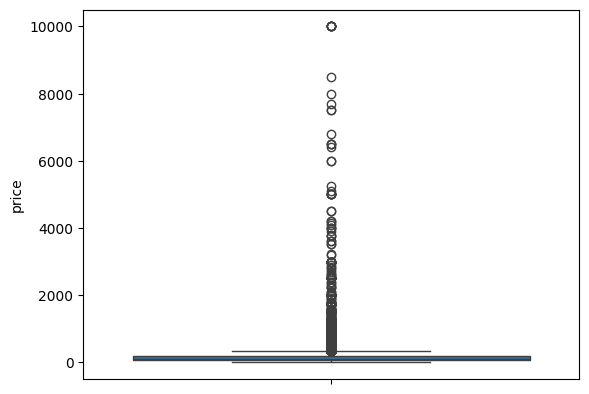

In [19]:
sns.boxplot(df['price'])
plt.show()

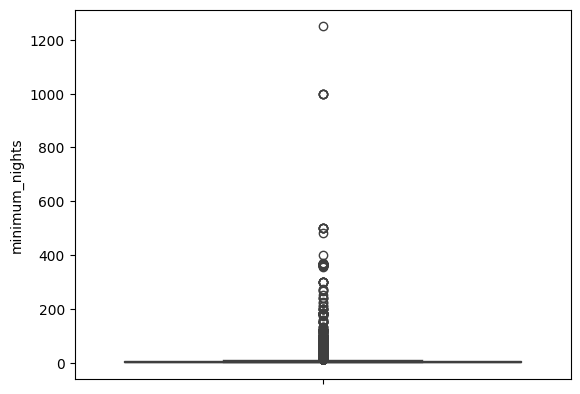

In [20]:
sns.boxplot(df['minimum_nights'])
plt.show()

**Written justification — for each outlier group, is it an error or a genuine listing? What evidence supports your call?**

Zero Price : Identified as an error (unrealistic listing). Capped at a minimum of 30.
Extreme Price (10000): Likely genuine luxury listings, but capped at 2000 to restrict extreme variance in model predictions.
Minimum Nights Outliers: Handled by capping using standard lower and upper percentile limits.

In [21]:
# TODO: apply treatment consistent with your judgment above

# PRICE
df.loc[df['price']<30,'price']=30
df.loc[df['price']>2000,'price']=2000


In [22]:
#minimum_nights
q1 = df['minimum_nights'].quantile(0.25)
q3 = df['minimum_nights'].quantile(0.75)

In [23]:
iqr = q3 - q1
up_lim = q3 + (1.5 * iqr)
low_lim = q1 - (1.5 * iqr)

df.loc[df['minimum_nights']<low_lim,'minimum_nights']=low_lim
df.loc[df['minimum_nights']>up_lim,'minimum_nights']=up_lim

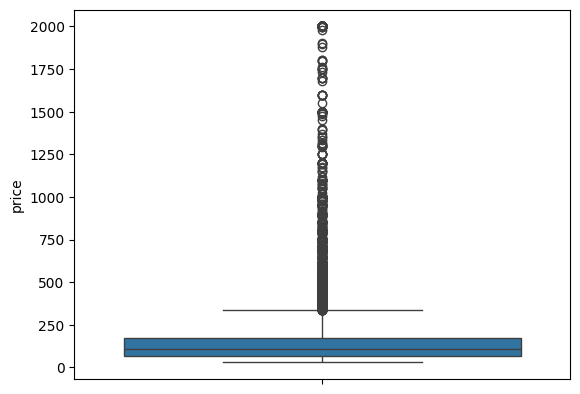

In [24]:
sns.boxplot(df['price'])
plt.show()

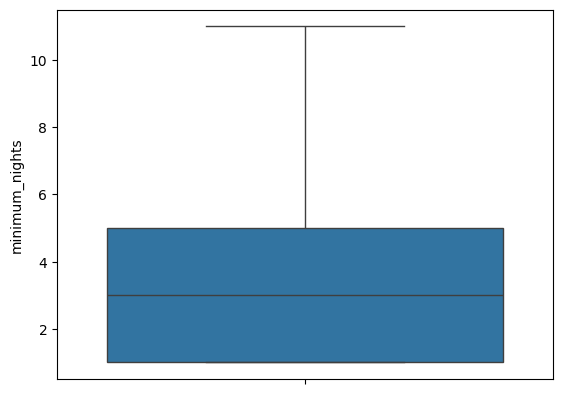

In [25]:
sns.boxplot(df['minimum_nights'])
plt.show()

---
## Part 4 — Feature Engineering & Encoding

In [26]:
# TODO: encode categorical columns appropriately
df['neighbourhood'].unique()


array(['Kensington', 'Midtown', 'Harlem', 'Clinton Hill', 'East Harlem',
       'Murray Hill', 'Bedford-Stuyvesant', "Hell's Kitchen",
       'Upper West Side', 'Chinatown', 'South Slope', 'West Village',
       'Williamsburg', 'Fort Greene', 'Chelsea', 'Crown Heights',
       'Park Slope', 'Windsor Terrace', 'Inwood', 'East Village',
       'Greenpoint', 'Bushwick', 'Flatbush', 'Lower East Side',
       'Prospect-Lefferts Gardens', 'Long Island City', 'Kips Bay',
       'SoHo', 'Upper East Side', 'Prospect Heights',
       'Washington Heights', 'Woodside', 'Brooklyn Heights',
       'Carroll Gardens', 'Gowanus', 'Flatlands', 'Cobble Hill',
       'Flushing', 'Boerum Hill', 'Sunnyside', 'DUMBO', 'St. George',
       'Highbridge', 'Financial District', 'Ridgewood',
       'Morningside Heights', 'Jamaica', 'Middle Village', 'NoHo',
       'Ditmars Steinway', 'Flatiron District', 'Roosevelt Island',
       'Greenwich Village', 'Little Italy', 'East Flatbush',
       'Tompkinsville', 'Asto

In [27]:
frequency = df['neighbourhood'].value_counts()
df['neighbourhood'] = df['neighbourhood'].map(frequency)
print(df['neighbourhood'])



0         175
1        1545
2        2658
3         572
4        1117
         ... 
48890    3714
48891    2465
48892    2658
48893    1958
48894    1958
Name: neighbourhood, Length: 48895, dtype: int64


In [28]:
df.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,175,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,1545,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,2658,40.80902,-73.94190,Private room,150,3,0,0.00,1,365
3,Brooklyn,572,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,1117,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


In [29]:
# TODO: engineer at least two new features

from sklearn.preprocessing import OrdinalEncoder
encoder= OrdinalEncoder(
    categories=[['Shared room', 'Private room', 'Entire home/apt']]
)
df['room_type']=encoder.fit_transform(df[['room_type']])


In [30]:
df['neighbourhood_group'].unique()

array(['Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'Bronx'],
      dtype=object)

In [31]:
df=pd.get_dummies(df,prefix='group',dtype='int',drop_first=True)

In [32]:
df.head()

,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,group_Brooklyn,group_Manhattan,group_Queens,group_Staten Island
0,175,40.64749,-73.97237,1.0,149,1,9,0.21,6,365,1,0,0,0
1,1545,40.75362,-73.98377,2.0,225,1,45,0.38,2,355,0,1,0,0
2,2658,40.80902,-73.94190,1.0,150,3,0,0.00,1,365,0,1,0,0
3,572,40.68514,-73.95976,2.0,89,1,270,4.64,1,194,1,0,0,0
4,1117,40.79851,-73.94399,2.0,80,10,9,0.10,1,0,0,1,0,0


In [33]:
df=df.drop(['latitude','longitude'],axis =1)

**Written justification — why these features, and which column(s) should NOT be used to predict price, and why:**

id, name, host_id, host_name, latitude, and longitude were dropped since they do not contribute to price prediction. Categorical columns were encoded based on their structure: Frequency Encoding for neighbourhood, Ordinal Encoding for room_type, and One-Hot Encoding for neighbourhood_group.

---
## Part 5 — Build a Reusable Preprocessing Pipeline

In [34]:
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [42]:
#  build Pipeline combining your cleaning, imputation, encoding, scaling steps
url = "https://raw.githubusercontent.com/erkansirin78/datasets/master/AB_NYC_2019.csv"
df = pd.read_csv(url)
df.head()


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [37]:
#Missing value handling
df=df.drop(['last_review','id','name','host_id','host_name','latitude','longitude'],axis=1)
df['reviews_per_month']=df['reviews_per_month'].fillna(0)

In [39]:
# Outlier handling

df.loc[df['price']<30,'price']=30
df.loc[df['price']>2000,'price']=2000

In [40]:
q1 = df['minimum_nights'].quantile(0.25)
q3 = df['minimum_nights'].quantile(0.75)

In [41]:
iqr = q3 - q1
up_lim = q3 + (1.5 * iqr)
low_lim = q1 - (1.5 * iqr)

df.loc[df['minimum_nights']<low_lim,'minimum_nights']=low_lim
df.loc[df['minimum_nights']>up_lim,'minimum_nights']=up_lim

In [43]:
#Encoding:
frequency = df['neighbourhood'].value_counts()
df['neighbourhood'] = df['neighbourhood'].map(frequency)
print(df['neighbourhood'])

0         175
1        1545
2        2658
3         572
4        1117
         ... 
48890    3714
48891    2465
48892    2658
48893    1958
48894    1958
Name: neighbourhood, Length: 48895, dtype: int64


In [44]:

# TODO: train/test split (before fitting anything)

x = df.drop('price',axis=1)
y = df['price']

x_train,x_test,y_train,y_test =train_test_split(
    x,y,test_size=0.2,random_state=42
)

In [45]:
numerical_columns = ['neighbourhood','minimum_nights','number_of_reviews','reviews_per_month','calculated_host_listings_count','availability_365']
nominal_columns = ['neighbourhood_group']
ordinal_columns = ['room_type']

In [46]:
numerical_pipeline = Pipeline([
    ('scalar',StandardScaler())
])

In [47]:
nominal_pipeline = Pipeline([
    ('encoder', OneHotEncoder(drop='first', sparse_output=False))
])

In [48]:
ordinal_pipeline = Pipeline([
    ('encoder',OrdinalEncoder(
        categories=[['Shared room', 'Private room', 'Entire home/apt']]
    ))
])

In [49]:
# Combine Pipelines
preprocessor = ColumnTransformer([
    ('numeric',numerical_pipeline,numerical_columns),
    ('nominal',nominal_pipeline,nominal_columns),
    ('ordinal', ordinal_pipeline, ordinal_columns)
])

In [50]:
# Fit and transform training data
x_train_preprocessed = preprocessor.fit_transform(x_train)
x_test_preprocessed = preprocessor.transform(x_test)

In [51]:
x_train.shape

(39116, 15)

---
## Part 6 — Written Reflection

1. _Your answer._
2. _Your answer._
3. _Your answer._